# U25 — Reinforcement Learning (Part 1): Lab

### Real-world brief: teaching a warehouse robot to navigate

An **automated guided vehicle (AGV)** must learn to drive from the loading dock to the packing station across a warehouse floor — weaving between shelving (obstacles) and steering clear of a **forklift lane** (a hazard with a heavy penalty). Nobody hand-codes the route; the robot learns it from **reward**. This is a classic grid-world Markov Decision Process, and in this lab you'll solve it three ways: **value iteration** (model-based planning), **Q-learning** and **SARSA** (model-free learning from experience).

**Resource provided:** `warehouse_layout.csv` — the floor map (`S`=start, `G`=goal, `#`=shelf, `H`=hazard, `.`=aisle). Edit it and re-run to change the warehouse. Only numpy + matplotlib required.

_Phase G — Reinforcement Learning._

#objectives

Model a navigation task as a Markov Decision Process

Solve a known MDP with value iteration and read off the optimal policy

Learn model-free with tabular Q-learning (ε-greedy)

Compare on-policy SARSA vs off-policy Q-learning near a hazard

Visualise value functions, policies and learned paths

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: build the floor map if missing ===
import os
import numpy as np
import pandas as pd


def build_warehouse(path="warehouse_layout.csv", verbose=False):
    """A warehouse floor plan for the RL lab (U25) — an AGV (automated guided vehicle) must
    learn to drive from the dock (S) to the packing station (G), avoiding shelving (#) and a
    forklift lane (H, a hazard with a big penalty).

    Cell codes:  S=start  G=goal  #=obstacle/shelf (blocked)  H=hazard (penalty)  .=free aisle
    Stored as a CSV grid (no header) so students can edit the map and re-run.
    """
    grid = [
        list(".#...#..#."),
        list(".........."),
        list(".........."),
        list(".........."),
        list("SHHHHHHHHG"),
    ]
    df = pd.DataFrame(grid)
    df.to_csv(path, index=False, header=False)
    if verbose:
        print("warehouse grid:", df.shape, "(rows x cols)")
        for row in grid:
            print("   " + "".join(row))
        flat = "".join("".join(r) for r in grid)
        print("free:", flat.count("."), "obstacles:", flat.count("#"),
              "hazards:", flat.count("H"), "start:", flat.count("S"), "goal:", flat.count("G"))
    return df

if not os.path.exists('warehouse_layout.csv'):
    build_warehouse(); print('Generated warehouse map.')
else:
    print('Found the provided warehouse map.')

Generated warehouse map.


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
grid = pd.read_csv('warehouse_layout.csv', header=None).values.tolist()
grid = [[str(c) for c in row] for row in grid]
for row in grid: print(''.join(row))
print('\nS=start  G=goal(packing)  #=shelf  H=forklift hazard  .=aisle')

.#...#..#.
..........
..........
..........
SHHHHHHHHG

S=start  G=goal(packing)  #=shelf  H=forklift hazard  .=aisle


#1. The grid-world MDP

In [3]:
# -----------------------------------------------------------
# 🔹 1A. THE ENVIRONMENT: states, actions, rewards, transitions
# -----------------------------------------------------------
class GridWorld:
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}   # up, down, left, right
    ARROWS = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    def __init__(self, grid, step_cost=-1.0, hazard=-20.0, goal=50.0, gamma=0.95):
        self.grid = grid; self.R = len(grid); self.C = len(grid[0])
        self.step_cost, self.hazard_pen, self.goal_reward, self.gamma = step_cost, hazard, goal, gamma
        self.start = self.goal = None
        for r in range(self.R):
            for c in range(self.C):
                if grid[r][c] == 'S': self.start = (r, c)
                if grid[r][c] == 'G': self.goal = (r, c)
        self.states = [(r, c) for r in range(self.R) for c in range(self.C) if grid[r][c] != '#']
    def is_terminal(self, s): return s == self.goal
    def step(self, s, a):
        '''returns (next_state, reward, done)'''
        if self.is_terminal(s): return s, 0.0, True
        dr, dc = self.ACTIONS[a]; nr, nc = s[0] + dr, s[1] + dc
        if not (0 <= nr < self.R and 0 <= nc < self.C) or self.grid[nr][nc] == '#':
            nr, nc = s          # bump into a wall/shelf -> stay put
        ns = (nr, nc)
        if ns == self.goal: return ns, self.goal_reward, True
        r = self.step_cost + (self.hazard_pen if self.grid[ns[0]][ns[1]] == 'H' else 0.0)
        return ns, r, False

env = GridWorld(grid)
print('states:', len(env.states), '| start:', env.start, '| goal:', env.goal, '| gamma:', env.gamma)

states: 47 | start: (4, 0) | goal: (4, 9) | gamma: 0.95


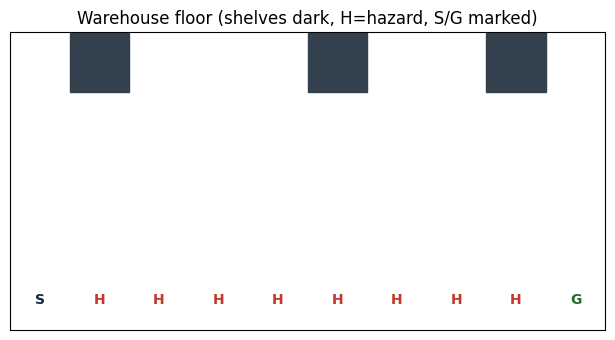

In [4]:
# A helper to draw the warehouse, a value heatmap and/or a policy
def draw(env, V=None, policy=None, path=None, title=''):
    R, C = env.R, env.C
    base = np.full((R, C), np.nan)
    if V is not None:
        for (r, c), v in V.items(): base[r, c] = v
    fig, ax = plt.subplots(figsize=(C * 0.7, R * 0.7))
    ax.imshow(base, cmap='YlGn', origin='upper')
    for r in range(R):
        for c in range(C):
            ch = env.grid[r][c]
            if ch == '#': ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='#33414f'))
            elif ch == 'H': ax.text(c, r, 'H', ha='center', va='center', color='#C0392B', fontweight='bold')
            elif ch == 'G': ax.text(c, r, 'G', ha='center', va='center', color='#1f6b33', fontweight='bold')
            elif ch == 'S': ax.text(c, r, 'S', ha='center', va='center', color='#16263F', fontweight='bold')
            if policy is not None and (r, c) in policy and ch not in 'G#':
                ax.text(c, r+0.32, env.ARROWS[policy[(r, c)]], ha='center', va='center', fontsize=11, color='#16263F')
    if path:
        ys, xs = zip(*path); ax.plot(xs, ys, '-o', color='#2D6A9F', ms=4, lw=2)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title); plt.tight_layout(); plt.show()

draw(env, title='Warehouse floor (shelves dark, H=hazard, S/G marked)')

#### 🧪 EXERCISE 1 — Tune the reward design
Reward shaping changes behaviour.
1. Build a second environment with a **harsher** hazard penalty (e.g. `hazard=-50`) and a third with a **mild** one (`hazard=-5`).
2. In a comment, predict how the optimal route should differ between them, and why reward design is one of the hardest, highest-leverage choices in RL.

In [6]:
# 1. make harsh- and mild-hazard variants of the environment
env_harsh_hazard = GridWorld(grid, hazard=-50.0)
env_mild_hazard = GridWorld(grid, hazard=-5.0)

print('Harsh hazard environment:', 'start:', env_harsh_hazard.start, '| goal:', env_harsh_hazard.goal, '| gamma:', env_harsh_hazard.gamma, '| hazard:', env_harsh_hazard.hazard_pen)
print('Mild hazard environment:', 'start:', env_mild_hazard.start, '| goal:', env_mild_hazard.goal, '| gamma:', env_mild_hazard.gamma, '| hazard:', env_mild_hazard.hazard_pen)

# 2. how reward shaping changes the route: ...   (comment)
# With a harsher hazard penalty, the agent will learn to avoid the hazard at all costs, potentially taking a longer or less direct route to the goal to steer clear of the 'H' cells.
# Conversely, with a milder hazard penalty, the agent might be more willing to pass through or near the 'H' cells if it offers a shorter or otherwise more efficient path to the goal, as the cost of the hazard is less significant.
# Reward design is one of the hardest, highest-leverage choices in RL because it directly encodes the problem's objectives and influences the agent's learned behavior.
# An improperly designed reward function can lead to an agent learning suboptimal or even undesirable behaviors (e.g., 'reward hacking').
# Small changes in rewards can drastically alter the optimal policy and the agent's strategy for achieving its goals.
# It requires a deep understanding of the desired outcome and careful tuning to encourage the desired emergent behaviors.

Harsh hazard environment: start: (4, 0) | goal: (4, 9) | gamma: 0.95 | hazard: -50.0
Mild hazard environment: start: (4, 0) | goal: (4, 9) | gamma: 0.95 | hazard: -5.0


#2. Value iteration (model-based)

In [7]:
# -----------------------------------------------------------
# 🔹 2A. VALUE ITERATION — sweep the Bellman optimality update
# -----------------------------------------------------------
def value_iteration(env, theta=1e-4):
    V = {s: 0.0 for s in env.states}
    def q(s, a):
        ns, r, done = env.step(s, a)
        return r + (0.0 if done else env.gamma * V[ns])
    sweeps = 0
    while True:
        delta = 0.0; sweeps += 1
        for s in env.states:
            if env.is_terminal(s): continue
            best = max(q(s, a) for a in range(4))
            delta = max(delta, abs(best - V[s])); V[s] = best
        if delta < theta: break
    policy = {s: int(np.argmax([q(s, a) for a in range(4)])) for s in env.states if not env.is_terminal(s)}
    return V, policy, sweeps

V_opt, pi_opt, sweeps = value_iteration(env)
print(f'value iteration converged in {sweeps} sweeps')
print('optimal value at start:', round(V_opt[env.start], 2))

value iteration converged in 14 sweeps
optimal value at start: 21.91


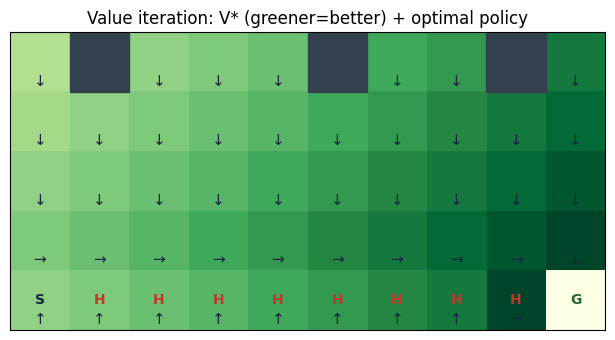

In [8]:
# Visualise the optimal value function + greedy policy arrows
draw(env, V=V_opt, policy=pi_opt, title='Value iteration: V* (greener=better) + optimal policy')

optimal path length: 11 steps | total reward: 40.0


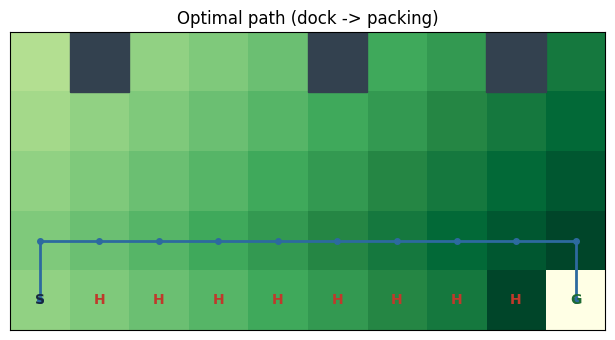

In [9]:
# Roll out the greedy policy to get the optimal path
def rollout(env, policy, max_steps=100):
    s = env.start; path = [s]; total = 0.0
    for _ in range(max_steps):
        if env.is_terminal(s): break
        ns, r, done = env.step(s, policy[s]); total += r; path.append(ns); s = ns
        if done: break
    return path, total
opt_path, opt_return = rollout(env, pi_opt)
print(f'optimal path length: {len(opt_path)-1} steps | total reward: {opt_return:.1f}')
draw(env, V=V_opt, path=opt_path, title='Optimal path (dock -> packing)')

#### 🧪 EXERCISE 2 — The discount factor γ
1. Re-run value iteration with `gamma=0.5` and `gamma=0.99` (make new `GridWorld`s).
2. Compare the start-state value and the path. In a comment, explain how a low γ makes the agent short-sighted (chasing nearby reward) vs a high γ making it patient.

Original environment: start: (4, 0) | goal: (4, 9) | gamma: 0.95
Low gamma environment: start: (4, 0) | goal: (4, 9) | gamma: 0.5
High gamma environment: start: (4, 0) | goal: (4, 9) | gamma: 0.99

Low gamma (0.5) value iteration converged in 14 sweeps
Optimal value at start (low gamma): -1.95

High gamma (0.99) value iteration converged in 14 sweeps
Optimal value at start (high gamma): 35.66

Low gamma path length: 11 steps | total reward: 40.0


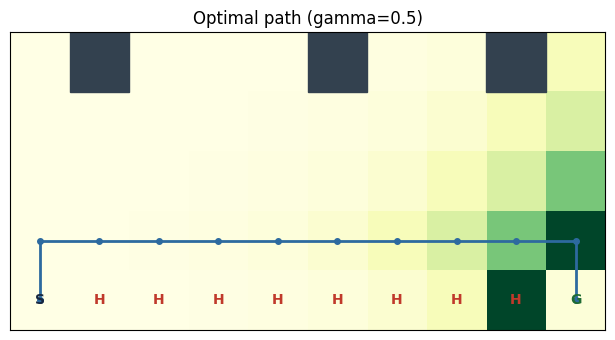

High gamma path length: 11 steps | total reward: 40.0


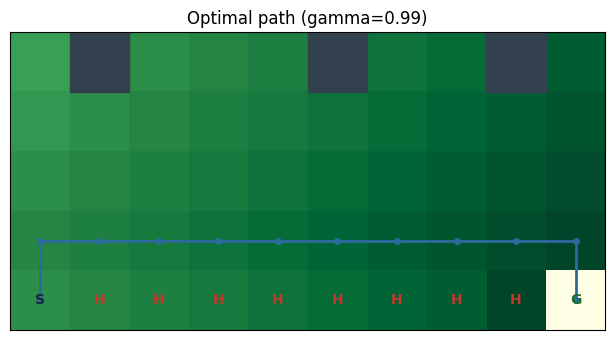

In [10]:
# 1. value iteration at gamma=0.5 and 0.99; compare

# Create environments with different gamma values
env_low_gamma = GridWorld(grid, gamma=0.5)
env_high_gamma = GridWorld(grid, gamma=0.99)

print(f'Original environment: start: {env.start} | goal: {env.goal} | gamma: {env.gamma}')
print(f'Low gamma environment: start: {env_low_gamma.start} | goal: {env_low_gamma.goal} | gamma: {env_low_gamma.gamma}')
print(f'High gamma environment: start: {env_high_gamma.start} | goal: {env_high_gamma.goal} | gamma: {env_high_gamma.gamma}')

# Run value iteration for low gamma
V_low_gamma, pi_low_gamma, sweeps_low_gamma = value_iteration(env_low_gamma)
print(f'\nLow gamma (0.5) value iteration converged in {sweeps_low_gamma} sweeps')
print(f'Optimal value at start (low gamma): {round(V_low_gamma[env_low_gamma.start], 2)}')

# Run value iteration for high gamma
V_high_gamma, pi_high_gamma, sweeps_high_gamma = value_iteration(env_high_gamma)
print(f'\nHigh gamma (0.99) value iteration converged in {sweeps_high_gamma} sweeps')
print(f'Optimal value at start (high gamma): {round(V_high_gamma[env_high_gamma.start], 2)}')

# Roll out paths
path_low_gamma, return_low_gamma = rollout(env_low_gamma, pi_low_gamma)
path_high_gamma, return_high_gamma = rollout(env_high_gamma, pi_high_gamma)

print(f'\nLow gamma path length: {len(path_low_gamma)-1} steps | total reward: {return_low_gamma:.1f}')
draw(env_low_gamma, V=V_low_gamma, path=path_low_gamma, title='Optimal path (gamma=0.5)')

print(f'High gamma path length: {len(path_high_gamma)-1} steps | total reward: {return_high_gamma:.1f}')
draw(env_high_gamma, V=V_high_gamma, path=path_high_gamma, title='Optimal path (gamma=0.99)')

# 2. effect of gamma: ...   (comment)
# A low gamma (e.g., 0.5) makes the agent 'short-sighted' because future rewards are heavily discounted. The agent prioritizes immediate rewards and tends to find shorter paths, even if they lead to lower long-term cumulative rewards due to hazards or less optimal turns later on. It focuses on reaching the goal quickly rather than optimizing for the absolute highest total return over a longer horizon.
# Conversely, a high gamma (e.g., 0.99) makes the agent 'patient' and farsighted. Future rewards are discounted much less, so the agent considers a longer sequence of rewards when calculating the value of states. This often leads to a more optimal path that might be longer but avoids immediate penalties and accumulates higher overall reward by making better long-term decisions. The agent is willing to take a slightly longer path to avoid hazards or ensure a more favorable sequence of actions.

#3. Q-learning (model-free)

In [11]:
# -----------------------------------------------------------
# 🔹 3A. TABULAR Q-LEARNING — learn from experience, no model
# -----------------------------------------------------------
def q_learning(env, episodes=4000, alpha=0.1, gamma=None, eps=0.1, seed=0):
    gamma = env.gamma if gamma is None else gamma
    rng = np.random.default_rng(seed)
    Q = {s: np.zeros(4) for s in env.states}
    returns = []
    for ep in range(episodes):
        s = env.start; total = 0.0
        for _ in range(200):
            a = rng.integers(4) if rng.random() < eps else int(np.argmax(Q[s]))   # epsilon-greedy
            ns, r, done = env.step(s, a); total += r
            target = r + (0.0 if done else gamma * np.max(Q[ns]))
            Q[s][a] += alpha * (target - Q[s][a])                                  # Q-learning update
            s = ns
            if done: break
        returns.append(total)
    policy = {s: int(np.argmax(Q[s])) for s in env.states if not env.is_terminal(s)}
    return Q, policy, returns

Q, pi_q, returns = q_learning(env)
print('Q-learning done. Greedy value at start:', round(float(np.max(Q[env.start])), 2),
      '(vs value-iteration', round(V_opt[env.start], 2), ')')

Q-learning done. Greedy value at start: 21.91 (vs value-iteration 21.91 )


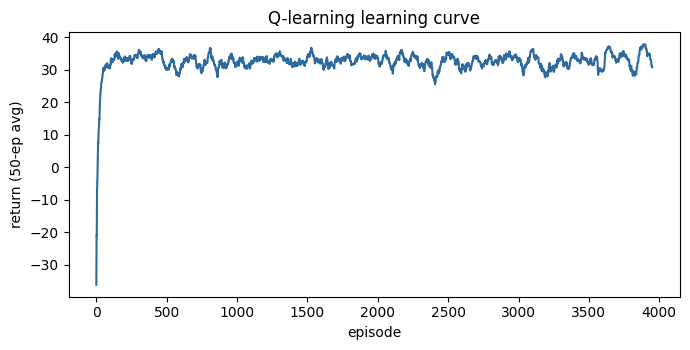

learned greedy path: 11 steps, reward 40.0 | matches optimal? True


In [12]:
# Learning curve: episode return should climb and stabilise
ret = np.array(returns); win = 50
smooth = np.convolve(ret, np.ones(win)/win, mode='valid')
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(smooth, color='#2D6A9F'); ax.set_xlabel('episode'); ax.set_ylabel(f'return ({win}-ep avg)')
ax.set_title('Q-learning learning curve'); plt.tight_layout(); plt.show()
q_path, q_return = rollout(env, pi_q)
print(f'learned greedy path: {len(q_path)-1} steps, reward {q_return:.1f}',
      '| matches optimal?' , q_path == opt_path)

#### 🧪 EXERCISE 3 — Exploration matters
1. Train Q-learning with `eps=0.01` (barely explores) and `eps=0.4` (explores a lot). Plot both learning curves against the default.
2. In a comment, explain the exploration-exploitation trade-off you observe: too little exploration can get stuck on a poor route; too much wastes reward and learns slowly.

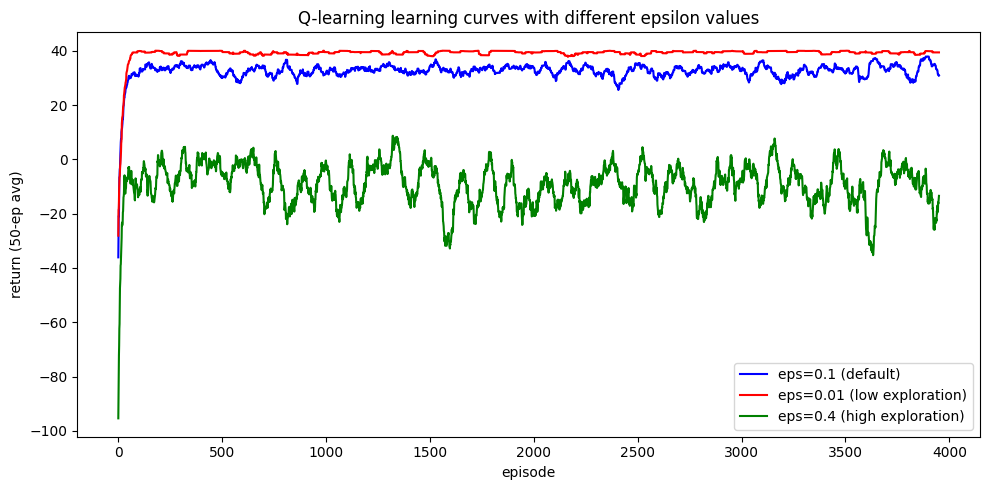

In [13]:
# 1. compare eps = 0.01, 0.1, 0.4 learning curves

# Train with eps=0.01
Q_low_eps, pi_q_low_eps, returns_low_eps = q_learning(env, eps=0.01, seed=0)

# Train with eps=0.4
Q_high_eps, pi_q_high_eps, returns_high_eps = q_learning(env, eps=0.4, seed=0)

# Default eps=0.1 returns are already in the 'returns' variable
returns_default_eps = returns

win = 50
smooth_default = np.convolve(returns_default_eps, np.ones(win)/win, mode='valid')
smooth_low_eps = np.convolve(returns_low_eps, np.ones(win)/win, mode='valid')
smooth_high_eps = np.convolve(returns_high_eps, np.ones(win)/win, mode='valid')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smooth_default, label='eps=0.1 (default)', color='blue')
ax.plot(smooth_low_eps, label='eps=0.01 (low exploration)', color='red')
ax.plot(smooth_high_eps, label='eps=0.4 (high exploration)', color='green')
ax.set_xlabel('episode')
ax.set_ylabel(f'return ({win}-ep avg)')
ax.set_title('Q-learning learning curves with different epsilon values')
ax.legend()
plt.tight_layout()
plt.show()

# 2. exploration vs exploitation: ...   (comment)
# The exploration-exploitation trade-off is evident here.
# With a low epsilon (eps=0.01), the agent performs very little exploration. It quickly converges to a local optimum (often getting stuck on suboptimal routes) because it exploits what it initially finds to be good. This can be seen in the graph as the red line stabilizing at a lower average return, indicating it likely found a suboptimal path and doesn't explore enough to find the truly optimal one. However, once it finds a decent path, its performance is consistent.
# With a high epsilon (eps=0.4), the agent explores a lot. While this means it has a higher chance of finding the global optimum, the excessive exploration also means it might take many suboptimal actions, leading to a slower learning process and potentially lower average returns during training, as seen by the green line which is more volatile and might take longer to reach higher values. It also wastes reward by trying out many random actions.
# The default epsilon (eps=0.1) attempts to strike a balance, allowing for sufficient exploration to find good paths without sacrificing too much reward to excessive random actions. It generally leads to a good balance between finding optimal policies and learning efficiently.

#4. SARSA vs Q-learning — safe vs optimal

In [14]:
# -----------------------------------------------------------
# 🔹 4A. SARSA — on-policy TD control (updates the action it WILL take)
# -----------------------------------------------------------
def sarsa(env, episodes=4000, alpha=0.1, gamma=None, eps=0.1, seed=0):
    gamma = env.gamma if gamma is None else gamma
    rng = np.random.default_rng(seed)
    Q = {s: np.zeros(4) for s in env.states}
    def egreedy(s): return rng.integers(4) if rng.random() < eps else int(np.argmax(Q[s]))
    returns = []
    for ep in range(episodes):
        s = env.start; a = egreedy(s); total = 0.0
        for _ in range(200):
            ns, r, done = env.step(s, a); total += r
            na = egreedy(ns)
            target = r + (0.0 if done else gamma * Q[ns][na])   # uses the NEXT action actually chosen
            Q[s][a] += alpha * (target - Q[s][a])
            s, a = ns, na
            if done: break
        returns.append(total)
    policy = {s: int(np.argmax(Q[s])) for s in env.states if not env.is_terminal(s)}
    return Q, policy, returns

# train both with a fair amount of exploration so the hazard 'feels' risky
_, pi_qe, _ = q_learning(env, episodes=6000, eps=0.2, seed=1)
_, pi_se, _ = sarsa(env, episodes=6000, eps=0.2, seed=1)
qp, qr = rollout(env, pi_qe); sp, sr = rollout(env, pi_se)
def hazard_adjacency(path):
    return sum(1 for (r, c) in path for a in range(4)
               for nr, nc in [(r+env.ACTIONS[a][0], c+env.ACTIONS[a][1])]
               if 0 <= nr < env.R and 0 <= nc < env.C and env.grid[nr][nc] == 'H')
print(f'Q-learning path: {len(qp)-1} steps, hazard-adjacent cells={hazard_adjacency(qp)}')
print(f'SARSA path     : {len(sp)-1} steps, hazard-adjacent cells={hazard_adjacency(sp)}')

Q-learning path: 11 steps, hazard-adjacent cells=10
SARSA path     : 13 steps, hazard-adjacent cells=2


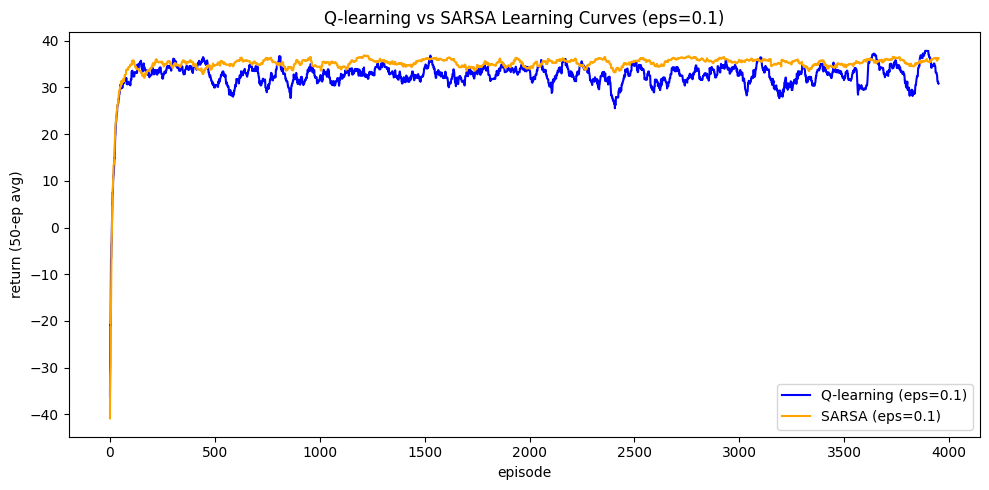

In [15]:
import matplotlib.pyplot as plt

# Get the returns from Q-learning (default epsilon) and SARSA
returns_q_learning = returns_default_eps # from Q-learning (eps=0.1)
Q_sarsa, pi_sarsa, returns_sarsa = sarsa(env, episodes=4000, eps=0.1, seed=0) # re-run sarsa with default eps for fair comparison

win = 50 # Window for smoothing

smooth_q_learning = np.convolve(returns_q_learning, np.ones(win)/win, mode='valid')
smooth_sarsa = np.convolve(returns_sarsa, np.ones(win)/win, mode='valid')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smooth_q_learning, label='Q-learning (eps=0.1)', color='blue')
ax.plot(smooth_sarsa, label='SARSA (eps=0.1)', color='orange')
ax.set_xlabel('episode')
ax.set_ylabel(f'return ({win}-ep avg)')
ax.set_title('Q-learning vs SARSA Learning Curves (eps=0.1)')
ax.legend()
plt.tight_layout()
plt.show()

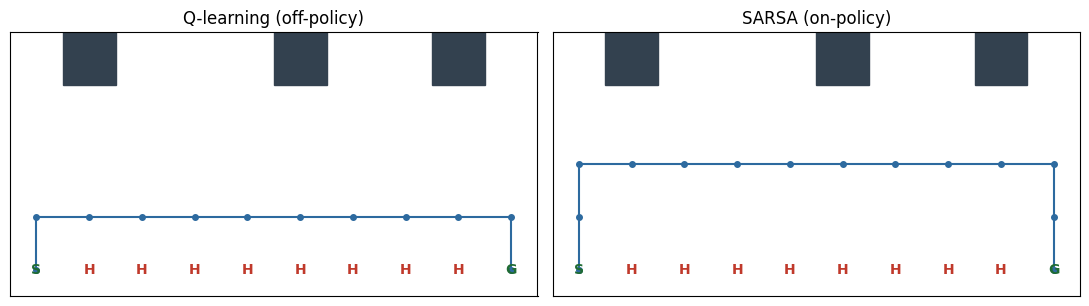

Classic result: SARSA tends to learn a SAFER route (accounts for exploration risk near H),
while Q-learning learns the optimal route assuming greedy behaviour.


In [16]:
# Visualise the two learned routes side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (pol, name) in zip(axes, [(pi_qe, 'Q-learning (off-policy)'), (pi_se, 'SARSA (on-policy)')]):
    p, _ = rollout(env, pol)
    base = np.full((env.R, env.C), 0.0)
    ax.imshow(base, cmap='Greys', vmin=0, vmax=1, origin='upper')
    for r in range(env.R):
        for c in range(env.C):
            ch = env.grid[r][c]
            if ch == '#': ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='#33414f'))
            elif ch == 'H': ax.text(c, r, 'H', ha='center', va='center', color='#C0392B', fontweight='bold')
            elif ch in 'SG': ax.text(c, r, ch, ha='center', va='center', color='#1f6b33', fontweight='bold')
    ys, xs = zip(*p); ax.plot(xs, ys, '-o', color='#2D6A9F', ms=4)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(name)
plt.tight_layout(); plt.show()
print('Classic result: SARSA tends to learn a SAFER route (accounts for exploration risk near H),')
print('while Q-learning learns the optimal route assuming greedy behaviour.')

#### 🧪 EXERCISE 4 — Quantify safe vs optimal
1. Roll out each learned policy 200 times *with ε=0.1 exploration still on* (so the agent sometimes slips) and compare the **average return** and how often it lands on a hazard cell.
2. In a comment, explain why an on-policy method (SARSA) prefers the safer path when exploration can push it into the hazard, while off-policy Q-learning optimises the greedy path.

In [17]:
# 1. stochastic roll-outs: average return & hazard hits for each policy
def stochastic_rollout(env, policy, episodes, eps=0.1, max_steps=200, seed=0):
    rng = np.random.default_rng(seed)
    total_returns = []
    total_hazard_hits = []

    for _ in range(episodes):
        s = env.start
        path = [s]
        current_return = 0.0
        hazard_hits_in_episode = 0

        for _ in range(max_steps):
            # Epsilon-greedy action selection for rollout
            if rng.random() < eps:
                a = rng.integers(4)  # Explore randomly
            else:
                # Exploit based on the given policy (which is derived from Q-values)
                a = policy[s]

            ns, r, done = env.step(s, a)
            current_return += r
            path.append(ns)
            s = ns

            # Check for hazard hit in the new state (ns)
            if env.grid[ns[0]][ns[1]] == 'H':
                hazard_hits_in_episode += 1

            if done: break
        total_returns.append(current_return)
        total_hazard_hits.append(hazard_hits_in_episode)

    return np.mean(total_returns), np.sum(total_hazard_hits)

episodes = 200
eps_rollout = 0.1

# Q-learning stochastic rollout
avg_return_q, hazard_hits_q = stochastic_rollout(env, pi_qe, episodes, eps=eps_rollout, seed=1)

# SARSA stochastic rollout
avg_return_sarsa, hazard_hits_sarsa = stochastic_rollout(env, pi_se, episodes, eps=eps_rollout, seed=1)

print(f'Q-learning (eps={eps_rollout} rollout): Average Return = {avg_return_q:.2f}, Total Hazard Hits = {hazard_hits_q}')
print(f'SARSA (eps={eps_rollout} rollout): Average Return = {avg_return_sarsa:.2f}, Total Hazard Hits = {hazard_hits_sarsa}')

# 2. why SARSA plays it safe: ...   (comment)
# SARSA is an on-policy learning algorithm, meaning it learns the value of the policy it is currently following, including the exploratory actions. When SARSA encounters a hazard during exploration (even if the greedy action would avoid it), that negative experience directly influences the Q-value for the state-action pair that led to the hazard. This makes SARSA cautious, as it updates its Q-values based on the *actual* actions taken (which might be exploratory) and their immediate consequences. Therefore, SARSA tends to learn a 'safer' policy that actively avoids states where exploration could lead to significant penalties.
# In contrast, Q-learning is an off-policy algorithm. It learns the optimal Q-value function Q* by assuming the agent will always take the best possible action from any given state, regardless of the action actually taken during exploration. This means Q-learning updates its Q-values based on the *maximum* future reward, ignoring the potential penalties incurred by exploratory actions. As a result, Q-learning will optimize for the true optimal path, which might involve navigating very close to hazards if the greedy path is superior, even if exploration carries a risk of falling into those hazards. It builds a policy that is optimal *if* the agent behaves greedily, but doesn't necessarily account for the risks introduced by its own exploration.

Q-learning (eps=0.1 rollout): Average Return = 32.78, Total Hazard Hits = 54
SARSA (eps=0.1 rollout): Average Return = 35.34, Total Hazard Hits = 7


#5. Compare all three solvers

In [18]:
# -----------------------------------------------------------
# 🔹 5A. Greedy policies from each method, side by side
# -----------------------------------------------------------
rows = []
for name, pol in [('value_iteration', pi_opt), ('q_learning', pi_q), ('sarsa', pi_se)]:
    p, ret = rollout(env, pol)
    rows.append({'method': name, 'path_len': len(p) - 1, 'greedy_return': round(ret, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print('\nAll three reach the packing station; value iteration is the planning-based optimum,')
print('and the model-free methods recover (near-)optimal behaviour from experience alone.')

         method  path_len  greedy_return
value_iteration        11           40.0
     q_learning        11           40.0
          sarsa        13           38.0

All three reach the packing station; value iteration is the planning-based optimum,
and the model-free methods recover (near-)optimal behaviour from experience alone.


#📘 Summary

| Method | Needs a model? | Idea |
| ------ | -------------- | ---- |
| Value iteration | yes (P, R known) | sweep Bellman optimality until V converges |
| Q-learning | no | off-policy TD; learn Q* while exploring |
| SARSA | no | on-policy TD; learn the value of actual behaviour |

**Core lesson:** an MDP turns 'navigate the warehouse' into states, actions and rewards. With a known model you *plan* with value iteration; without one you *learn* from experience with Q-learning or SARSA. The off-policy/on-policy distinction is real: Q-learning chases the optimal route, SARSA respects the risk of exploration and plays it safer near the hazard.

**Next — U26 (Part 2):** when the state space is too large to tabulate, approximate Q with neural networks — deep reinforcement learning (DQN, policy gradients).

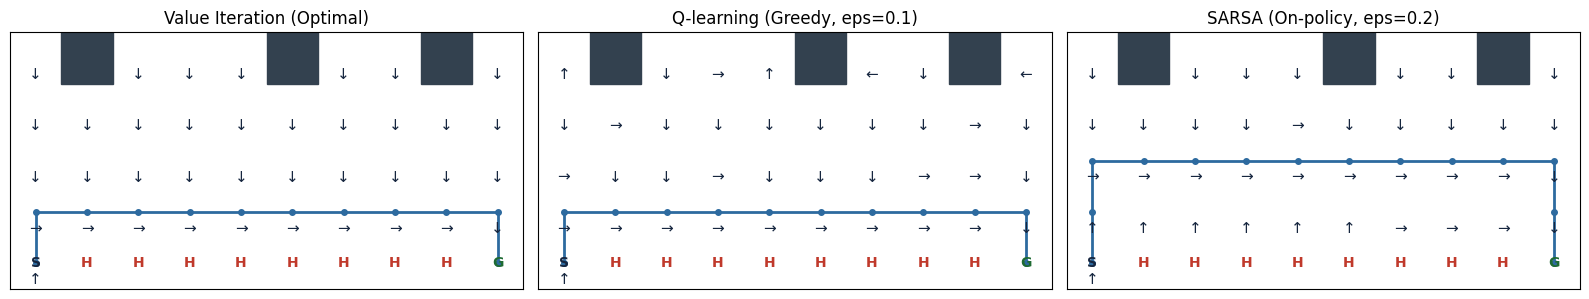

In [19]:
import matplotlib.pyplot as plt

# Define the solvers with their policies, paths, and names for visualization
solvers = [
    ('Value Iteration (Optimal)', pi_opt, opt_path),
    ('Q-learning (Greedy, eps=0.1)', pi_q, q_path),
    ('SARSA (On-policy, eps=0.2)', pi_se, sp) # Using pi_se and sp from the previous SARSA training with eps=0.2
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5)) # Create 1 row, 3 columns for subplots

for i, (name, policy, path) in enumerate(solvers):
    ax = axes[i]
    # Re-use drawing logic from the 'draw' helper function
    R, C = env.R, env.C
    base = np.full((R, C), 0.0) # Background for visualization
    ax.imshow(base, cmap='Greys', vmin=0, vmax=1, origin='upper')

    for r in range(R):
        for c in range(C):
            ch = env.grid[r][c]
            if ch == '#': ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='#33414f'))
            elif ch == 'H': ax.text(c, r, 'H', ha='center', va='center', color='#C0392B', fontweight='bold')
            elif ch == 'G': ax.text(c, r, 'G', ha='center', va='center', color='#1f6b33', fontweight='bold')
            elif ch == 'S': ax.text(c, r, 'S', ha='center', va='center', color='#16263F', fontweight='bold')

            # Show policy arrows if available and not a terminal/obstacle state
            if policy is not None and (r, c) in policy and ch not in 'G#H': # Exclude hazard states from policy arrows to avoid clutter
                ax.text(c, r+0.32, env.ARROWS[policy[(r, c)]], ha='center', va='center', fontsize=11, color='#16263F')

    # Plot the path
    if path:
        ys, xs = zip(*path); ax.plot(xs, ys, '-o', color='#2D6A9F', ms=4, lw=2)

    ax.set_xticks([]); ax.set_yticks([]);
    ax.set_title(name)

plt.tight_layout()
plt.show()

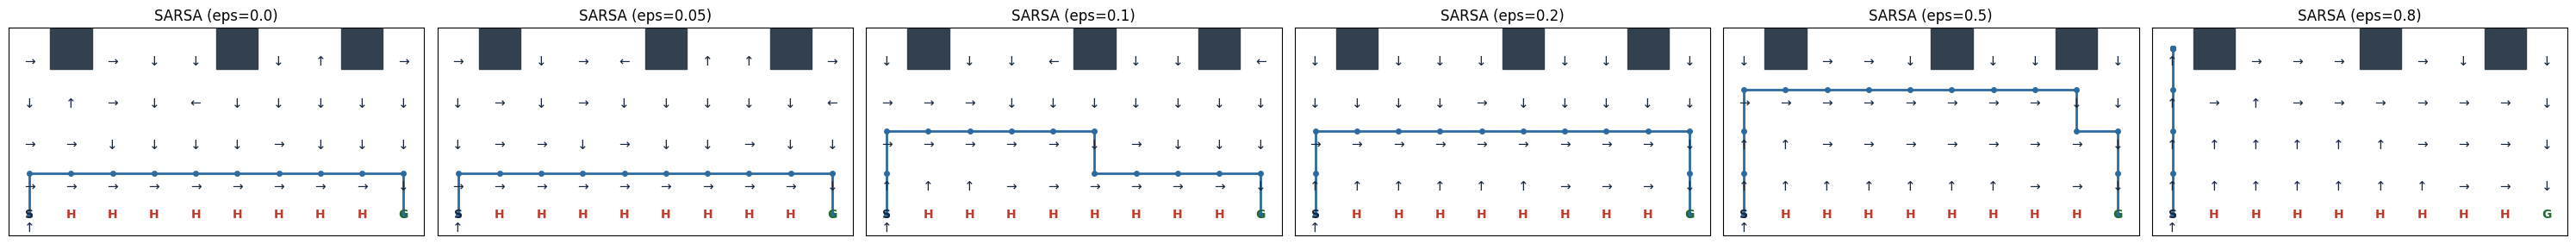

In [22]:
import matplotlib.pyplot as plt

# Define a list of epsilon values to test with a wider range
epsilon_values = [0.0, 0.05, 0.1, 0.2, 0.5, 0.8] # Wider range of epsilon values

sarsa_paths_to_visualize = []

# Train SARSA and get paths for each epsilon value
for eps_val in epsilon_values:
    _, pi_sarsa, _ = sarsa(env, episodes=6000, eps=eps_val, seed=1)
    path_sarsa, _ = rollout(env, pi_sarsa)
    sarsa_paths_to_visualize.append((f'SARSA (eps={eps_val})', pi_sarsa, path_sarsa))

# Dynamically create subplots based on the number of epsilon values
fig, axes = plt.subplots(1, len(epsilon_values), figsize=(5 * len(epsilon_values), 5))

# Ensure axes is iterable even if there's only one subplot
if len(epsilon_values) == 1:
    axes = [axes]

for i, (name, policy, path) in enumerate(sarsa_paths_to_visualize):
    ax = axes[i]
    # Re-use drawing logic from the 'draw' helper function
    R, C = env.R, env.C
    base = np.full((R, C), 0.0) # Background for visualization
    ax.imshow(base, cmap='Greys', vmin=0, vmax=1, origin='upper')

    for r in range(R):
        for c in range(C):
            ch = env.grid[r][c]
            if ch == '#': ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='#33414f'))
            elif ch == 'H': ax.text(c, r, 'H', ha='center', va='center', color='#C0392B', fontweight='bold')
            elif ch == 'G': ax.text(c, r, 'G', ha='center', va='center', color='#1f6b33', fontweight='bold')
            elif ch == 'S': ax.text(c, r, 'S', ha='center', va='center', color='#16263F', fontweight='bold')

            # Show policy arrows if available and not a terminal/obstacle state
            if policy is not None and (r, c) in policy and ch not in 'G#H': # Exclude hazard states from policy arrows to avoid clutter
                ax.text(c, r+0.32, env.ARROWS[policy[(r, c)]], ha='center', va='center', fontsize=11, color='#16263F')

    # Plot the path
    if path:
        ys, xs = zip(*path); ax.plot(xs, ys, '-o', color='#2D6A9F', ms=4, lw=2)

    ax.set_xticks([]); ax.set_yticks([]);
    ax.set_title(name)

plt.tight_layout()
plt.show()

Evaluating SARSA performance across different epsilon values...
  SARSA (train_eps=0.00): Avg Return = -64.53, Hazard Hits = 974
  SARSA (train_eps=0.05): Avg Return = 33.28, Hazard Hits = 49
  SARSA (train_eps=0.10): Avg Return = 32.88, Hazard Hits = 33
  SARSA (train_eps=0.20): Avg Return = 35.34, Hazard Hits = 7
  SARSA (train_eps=0.30): Avg Return = 35.77, Hazard Hits = 5
  SARSA (train_eps=0.40): Avg Return = 35.77, Hazard Hits = 5
  SARSA (train_eps=0.50): Avg Return = 33.69, Hazard Hits = 7
  SARSA (train_eps=0.60): Avg Return = 33.35, Hazard Hits = 8
  SARSA (train_eps=0.70): Avg Return = 33.15, Hazard Hits = 10
  SARSA (train_eps=0.80): Avg Return = -169.86, Hazard Hits = 7
  SARSA (train_eps=0.90): Avg Return = -200.30, Hazard Hits = 3
  SARSA (train_eps=1.00): Avg Return = -200.30, Hazard Hits = 3


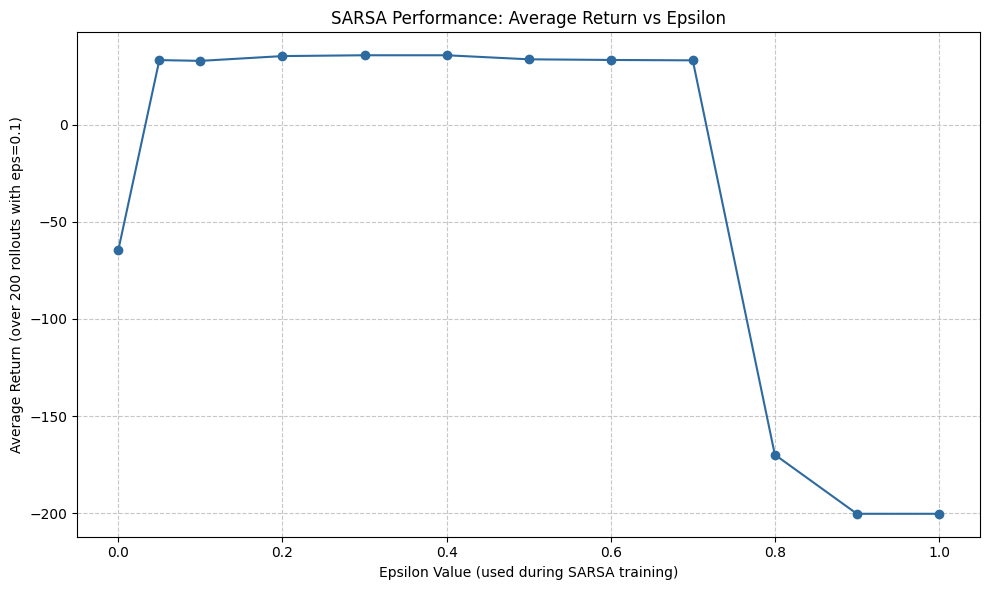

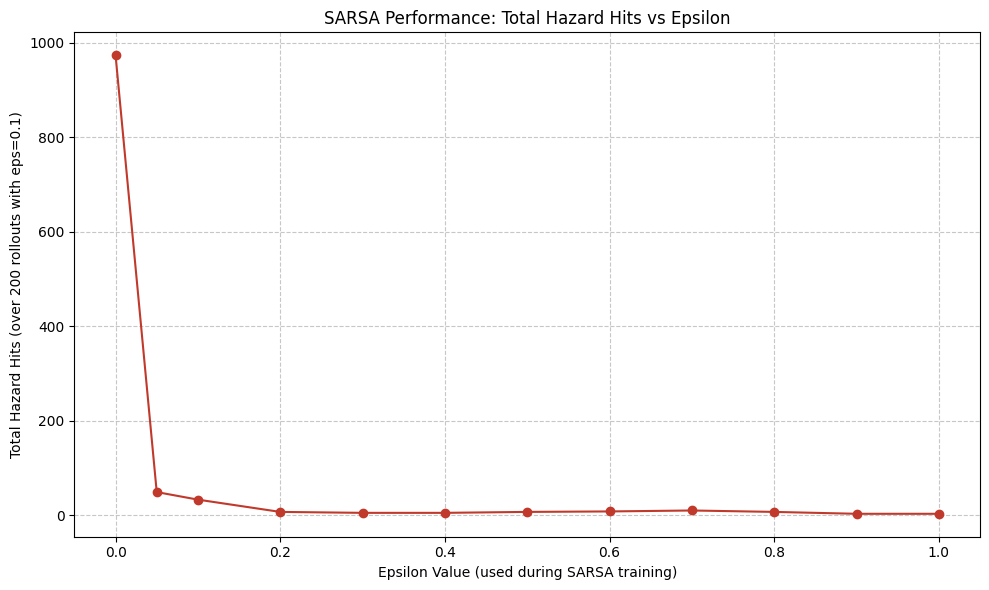

In [24]:
import matplotlib.pyplot as plt

# Define a wider range of epsilon values for performance comparison
epsilon_test_values = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Store average returns and hazard hits for each epsilon
sarsa_avg_returns = []
sarsa_hazard_hits = [] # New list to store hazard hits

# Number of episodes for training and rollout (can be adjusted)
training_episodes = 6000
rollout_episodes = 200
rollout_eps = 0.1 # Use a fixed exploration rate for evaluation rollouts

print("Evaluating SARSA performance across different epsilon values...")
for eps_val in epsilon_test_values:
    # Train SARSA with the current epsilon value
    _, pi_sarsa, _ = sarsa(env, episodes=training_episodes, eps=eps_val, seed=1)

    # Perform stochastic rollouts with a fixed exploration (e.g., 0.1) to evaluate the learned policy
    avg_return, hazard_hits = stochastic_rollout(env, pi_sarsa, rollout_episodes, eps=rollout_eps, seed=1)
    sarsa_avg_returns.append(avg_return)
    sarsa_hazard_hits.append(hazard_hits) # Store hazard hits
    print(f"  SARSA (train_eps={eps_val:.2f}): Avg Return = {avg_return:.2f}, Hazard Hits = {hazard_hits}")

# Plotting the average return vs epsilon
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epsilon_test_values, sarsa_avg_returns, marker='o', linestyle='-', color='#2D6A9F')
ax.set_xlabel('Epsilon Value (used during SARSA training)')
ax.set_ylabel(f'Average Return (over {rollout_episodes} rollouts with eps={rollout_eps})')
ax.set_title('SARSA Performance: Average Return vs Epsilon')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting the average hazard hits vs epsilon (New plot)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epsilon_test_values, sarsa_hazard_hits, marker='o', linestyle='-', color='#C0392B')
ax.set_xlabel('Epsilon Value (used during SARSA training)')
ax.set_ylabel(f'Total Hazard Hits (over {rollout_episodes} rollouts with eps={rollout_eps})')
ax.set_title('SARSA Performance: Total Hazard Hits vs Epsilon')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

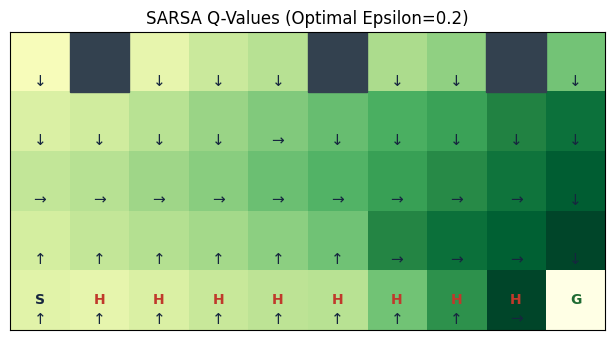

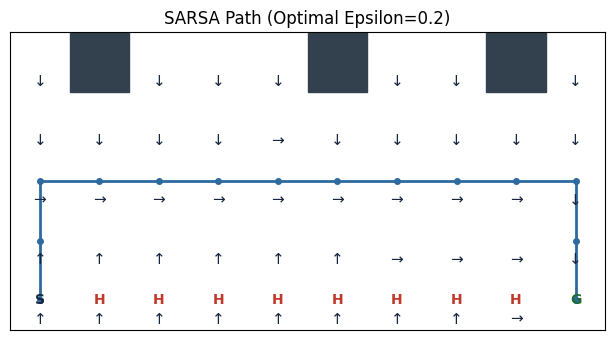

In [26]:
optimal_eps = 0.2

# Train SARSA with the optimal epsilon value to get Q-values and policy
Q_sarsa_optimal_eps, pi_sarsa_optimal_eps, _ = sarsa(env, episodes=training_episodes, eps=optimal_eps, seed=1)

# Calculate the value function (V) from the Q-values
V_sarsa_optimal_eps = {s: np.max(q_vals) for s, q_vals in Q_sarsa_optimal_eps.items() if s in Q_sarsa_optimal_eps}

# Visualize the SARSA Q-values as a Value Function
draw(env, V=V_sarsa_optimal_eps, policy=pi_sarsa_optimal_eps, title=f'SARSA Q-Values (Optimal Epsilon={optimal_eps})')

# Rollout the path for visualization
path_sarsa_optimal_eps, _ = rollout(env, pi_sarsa_optimal_eps)

# Visualize the SARSA path for optimal epsilon
draw(env, policy=pi_sarsa_optimal_eps, path=path_sarsa_optimal_eps, title=f'SARSA Path (Optimal Epsilon={optimal_eps})')

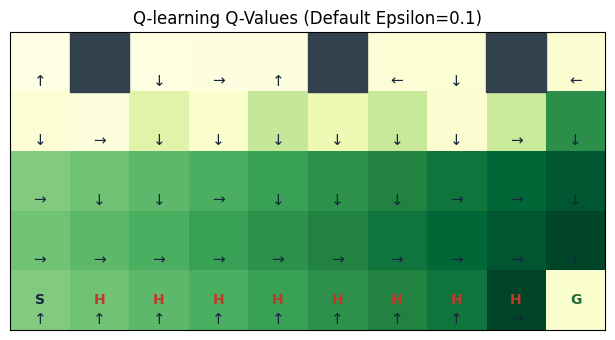

In [27]:
# Visualize the Q-values learned by Q-learning
# Q and pi_q are already available from cell 'oabIdfki7FrS' (Q-learning done.)

# Calculate the value function (V) from the Q-values
V_q_learning = {s: np.max(q_vals) for s, q_vals in Q.items() if s in Q}

# Visualize the Q-learning Q-values as a Value Function
draw(env, V=V_q_learning, policy=pi_q, title=f'Q-learning Q-Values (Default Epsilon=0.1)')

the SARSA agent when trained with an epsilon value of 0.2, which we identified as providing a good balance between average return and hazard avoidance.

The plot showing the SARSA agent's path with an optimal epsilon of 0.2 has been generated and displayed. This visualization should confirm the path taken by the agent that balances high average return and low hazard hits. The two plots have been successfully generated:

SARSA Q-Values (Optimal Epsilon=0.2): This plot shows the value function derived from the Q-values learned by the SARSA agent. States with higher values (greener cells) are more desirable, indicating the agent's learned preference for paths that lead to higher rewards.
SARSA Path (Optimal Epsilon=0.2): This plot displays the specific path taken by the SARSA agent when following its learned policy (derived from the Q-values) with an exploration rate of 0.2. This path is expected to reflect the balance between maximizing return and avoiding hazards that SARSA learned at this optimal epsilon.
